In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("world_happiness_2026.csv")

In [3]:
df.head()

,rank,country,region,score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,generosity,corruption
0,1,Finland,Western Europe,7.764,1.892,1.581,0.952,0.670,0.186,0.498
1,2,Iceland,Western Europe,7.701,1.874,1.611,0.959,0.662,0.269,0.512
2,3,Denmark,Western Europe,7.688,1.887,1.562,0.948,0.665,0.211,0.495
3,4,Costa Rica,Latin America and Caribbean,7.439,1.254,1.421,0.891,0.631,0.178,0.312
4,5,Sweden,Western Europe,7.401,1.878,1.501,0.952,0.658,0.224,0.481


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   rank                     147 non-null    int64  
 1   country                  147 non-null    object 
 2   region                   147 non-null    object 
 3   score                    147 non-null    float64
 4   gdp_per_capita           147 non-null    float64
 5   social_support           147 non-null    float64
 6   healthy_life_expectancy  147 non-null    float64
 7   freedom                  147 non-null    float64
 8   generosity               147 non-null    float64
 9   corruption               147 non-null    float64
dtypes: float64(7), int64(1), object(2)
memory usage: 11.6+ KB


In [5]:
df.isnull().sum()

rank                       0
country                    0
region                     0
score                      0
gdp_per_capita             0
social_support             0
healthy_life_expectancy    0
freedom                    0
generosity                 0
corruption                 0
dtype: int64

In [6]:
df.tail()

,rank,country,region,score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,generosity,corruption
142,143,Zimbabwe,Sub-Saharan Africa,2.811,0.341,0.621,0.381,0.211,0.091,0.011
143,144,Congo DR,Sub-Saharan Africa,2.761,0.191,0.601,0.311,0.201,0.141,0.011
144,145,South Sudan,Sub-Saharan Africa,2.711,0.251,0.581,0.251,0.181,0.131,0.011
145,146,Rwanda,Sub-Saharan Africa,2.661,0.391,0.701,0.431,0.381,0.201,0.141
146,147,Afghanistan,South Asia,1.446,0.241,0.341,0.361,0.071,0.071,0.011


In [7]:
df.describe()

,rank,score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,generosity,corruption
count,147.000000,147.000000,147.000000,147.000000,147.000000,147.000000,147.000000,147.000000
mean,74.000000,5.205694,1.043095,1.122279,0.694075,0.457673,0.162884,0.161340
std,42.579338,1.393472,0.588589,0.291444,0.212594,0.135096,0.054843,0.135871
min,1.000000,1.446000,0.171000,0.341000,0.251000,0.071000,0.061000,0.011000
25%,37.500000,3.901000,0.471000,0.851000,0.491000,0.371000,0.131000,0.051000
50%,74.000000,5.431000,1.021000,1.181000,0.771000,0.481000,0.161000,0.121000
75%,110.500000,6.291000,1.596000,1.361000,0.881000,0.561000,0.196000,0.246000
max,147.000000,7.764000,2.121000,1.611000,0.961000,0.671000,0.301000,0.512000


In [8]:
corr_matrix = df.select_dtypes(include =['number']).corr()

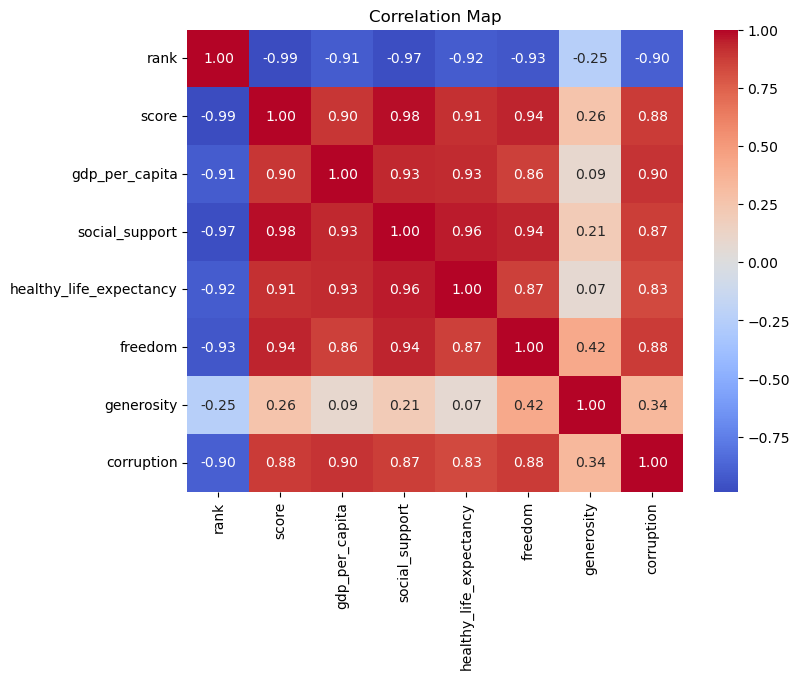

In [9]:
plt.figure(figsize = (8,6))
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', fmt = '.2f', cbar = True)
plt.title('Correlation Map')
plt.show()

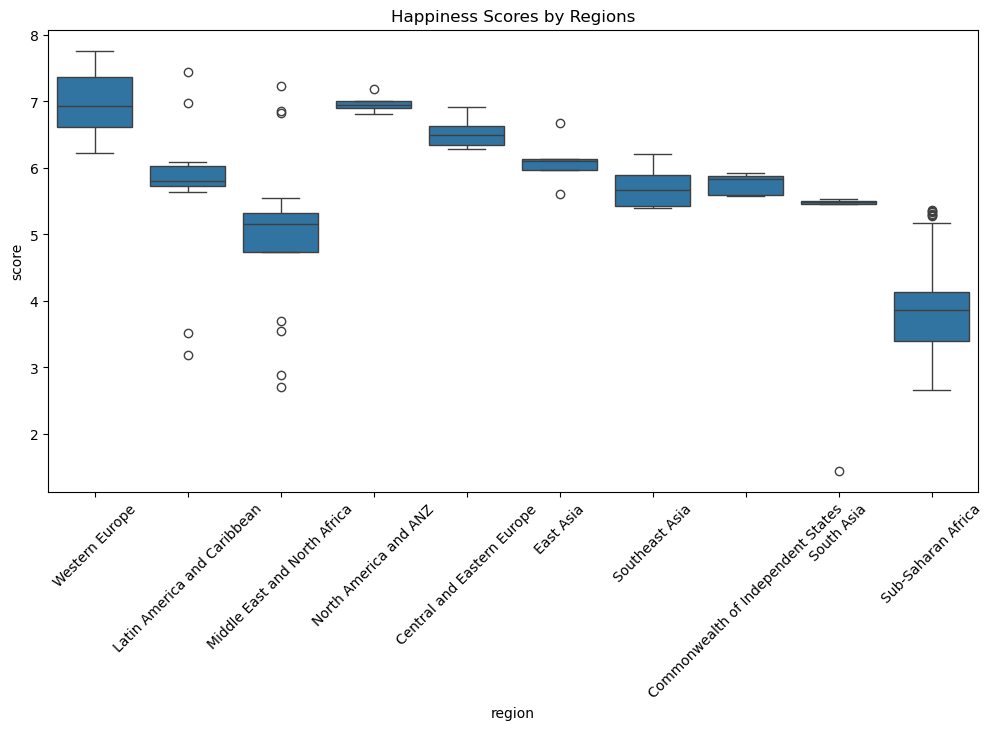

In [12]:
plt.figure(figsize = (12,6))
sns.boxplot(df, x = "region", y= "score")
plt.xticks(rotation = 45)
plt.title("Happiness Scores by Regions")
plt.show()

#### Conclusion

While Western Europe appears stable in the score parameter, there are fluctuations in the same matric in Americas and Middle East.

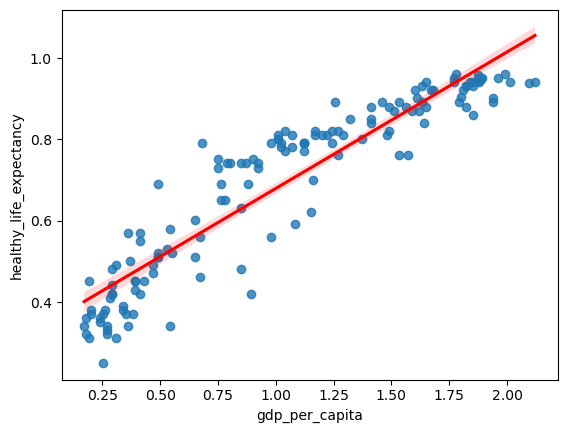

In [14]:
sns.regplot(df, x= "gdp_per_capita", y= "healthy_life_expectancy", line_kws = {"color":"red"})
plt.show()

It looks as it expected.

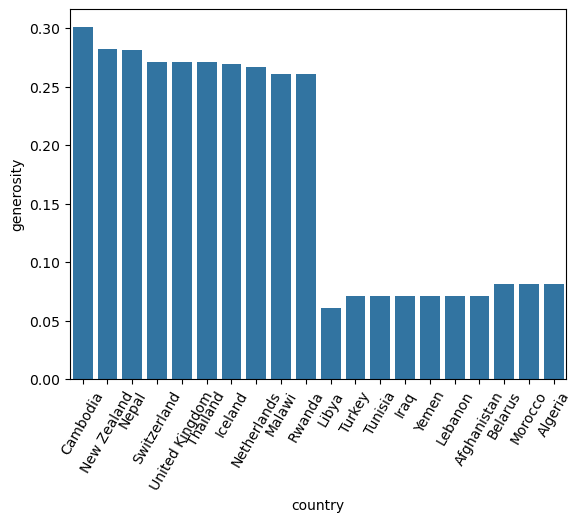

In [18]:
top_bottom = pd.concat([df.nlargest(10, "generosity"), df.nsmallest(10, "generosity")])
sns.barplot(top_bottom, x = "country", y = "generosity")
plt.xticks(rotation = 60)
plt.show()

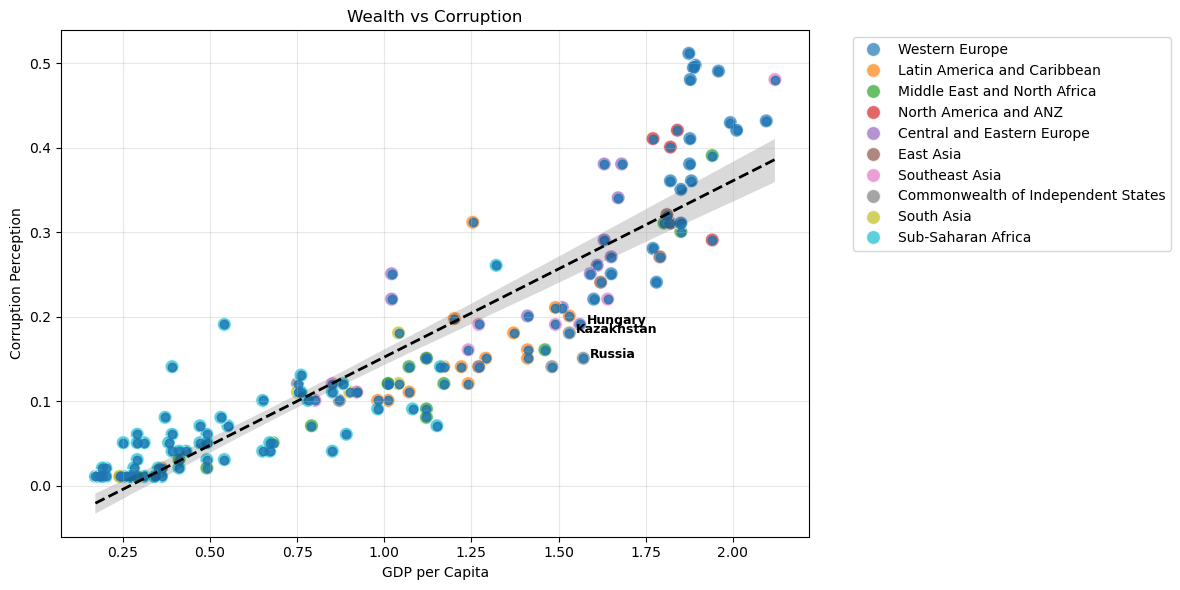

In [87]:
plt.figure(figsize = (12,6))
sns.scatterplot(df, x = "gdp_per_capita", y = "corruption",s = 100, hue = "region", alpha = 0.7)
sns.regplot(df, x = "gdp_per_capita", y = "corruption", line_kws = {"ls":"--", "lw":2, "color":"black"})

outliers = df[((df["gdp_per_capita"] > 1.5) & (df["corruption"] < 0.2)) | ((df["gdp_per_capita"] < 1.0) & (df["corruption"] > 0.3))]

for i in range(outliers.shape[0]):
    plt.text(outliers["gdp_per_capita"].iloc[i]+0.02, outliers["corruption"].iloc[i],
             outliers["country"].iloc[i], fontsize = 9, weight = "semibold")

plt.title("Wealth vs Corruption")
plt.xlabel("GDP per Capita")
plt.ylabel("Corruption Perception")
plt.legend(bbox_to_anchor = (1.05, 1), loc = "upper left")
plt.grid(alpha =0.3)
plt.tight_layout()
plt.savefig('wealth-vs-corruption.png')
plt.show()

Looks like Hungary, Kazakhstan, and Russia are more corrupt than expected relative to their wealth.

In [31]:
from scipy.stats import norm

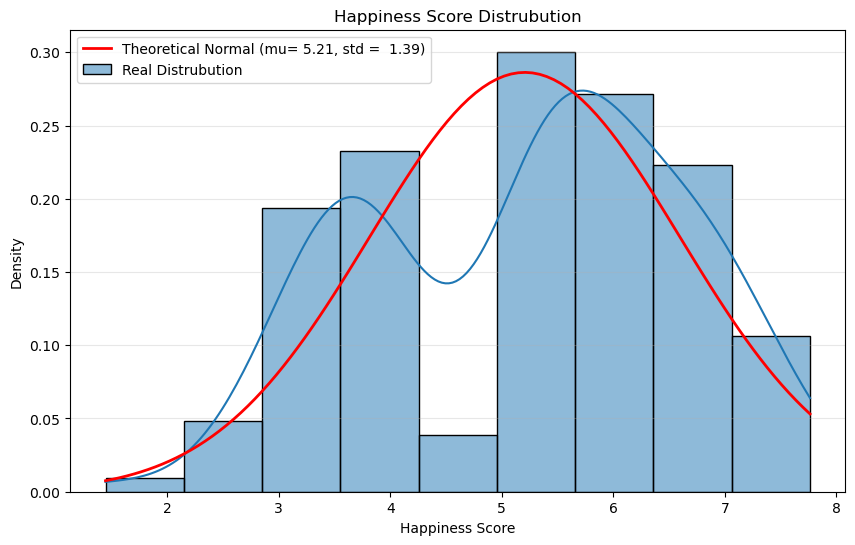

In [85]:
plt.figure(figsize = (10,6))
sns.histplot(df, x = "score", kde = True, stat = "density", label = "Real Distrubution")

mu, std = df["score"].mean(), df["score"].std()
x = np.linspace(df["score"].min(), df["score"].max(), 100)
# probability density function
p = norm.pdf(x, mu, std)
plt.plot(x, p, "r", linewidth = 2, label = f"Theoretical Normal (mu={mu: .2f}, std = {std: .2f})")

plt.title("Happiness Score Distrubution")
plt.xlabel("Happiness Score")
plt.ylabel("Density")
plt.legend()
plt.grid(axis = "y", alpha = 0.3)
plt.savefig('happiness-score-distribution.png')
plt.show()

## Insights of Score Distrubution

The Happiness Score distrubution exhibits **biomodality**, signaling a clear divide in global well-being. This pattern suggests that
countries are predominantly polarized into two groups: those struggling with systemic development issues and those established high-quality
life standarts. The scarcity of data points in the middle range highlights a "development gap", suggesting that transitioning from the lower
cluster to the upper one is a significant structural hurdle.

## Feature Engineering

In [50]:
df_clean = pd.get_dummies(df, columns = ["region"])

In [51]:
df_clean = df.drop(columns = ["rank", "region"], axis = 1)

In [52]:
df_clean.head()

,country,score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,generosity,corruption
0,Finland,7.764,1.892,1.581,0.952,0.670,0.186,0.498
1,Iceland,7.701,1.874,1.611,0.959,0.662,0.269,0.512
2,Denmark,7.688,1.887,1.562,0.948,0.665,0.211,0.495
3,Costa Rica,7.439,1.254,1.421,0.891,0.631,0.178,0.312
4,Sweden,7.401,1.878,1.501,0.952,0.658,0.224,0.481


## Model Training and Feature Importance

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [54]:
X = df_clean.drop(columns = ["country", "score"])
y = df_clean["score"]

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state =42)

In [57]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state = 42)
}

In [72]:
trained_models = {}
results = []
for name, model in models.items():
    model.fit(X_train, y_train)

    trained_models[name] = model
    
    preds = model.predict(X_test)

    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)

    results.append({"Model": name, "R2 Score": r2, "Root Mean Squarred Error": rmse, "Mean Absolute Error": mae})
    

In [73]:
results_df = pd.DataFrame(results)
results_df

,Model,R2 Score,Root Mean Squarred Error,Mean Absolute Error
0,Linear Regression,0.976461,0.208520,0.166502
1,Ridge,0.970279,0.234309,0.172037
2,Random Forest Regressor,0.982335,0.180637,0.128831


In [75]:
lr_model = trained_models["Linear Regression"]

lr_feat_importance = pd.DataFrame({"Feature": X.columns, "Coefficient": lr_model.coef_})
lr_feat_importance = lr_feat_importance.sort_values(by = "Coefficient", ascending=False)

In [76]:
lr_feat_importance

,Feature,Coefficient
1,social_support,6.194393
5,corruption,2.312930
3,freedom,0.230917
0,gdp_per_capita,-0.691025
4,generosity,-1.107816
2,healthy_life_expectancy,-1.720710


In [77]:
rf_model = trained_models["Random Forest Regressor"]

rf_feat_importance = pd.DataFrame({"Feature": X.columns, "Coefficient": rf_model.feature_importances_})
rf_feat_importance = rf_feat_importance.sort_values(by = "Coefficient", ascending=False)

In [78]:
rf_feat_importance

,Feature,Coefficient
1,social_support,0.859093
3,freedom,0.071732
5,corruption,0.045804
2,healthy_life_expectancy,0.010892
0,gdp_per_capita,0.007902
4,generosity,0.004578


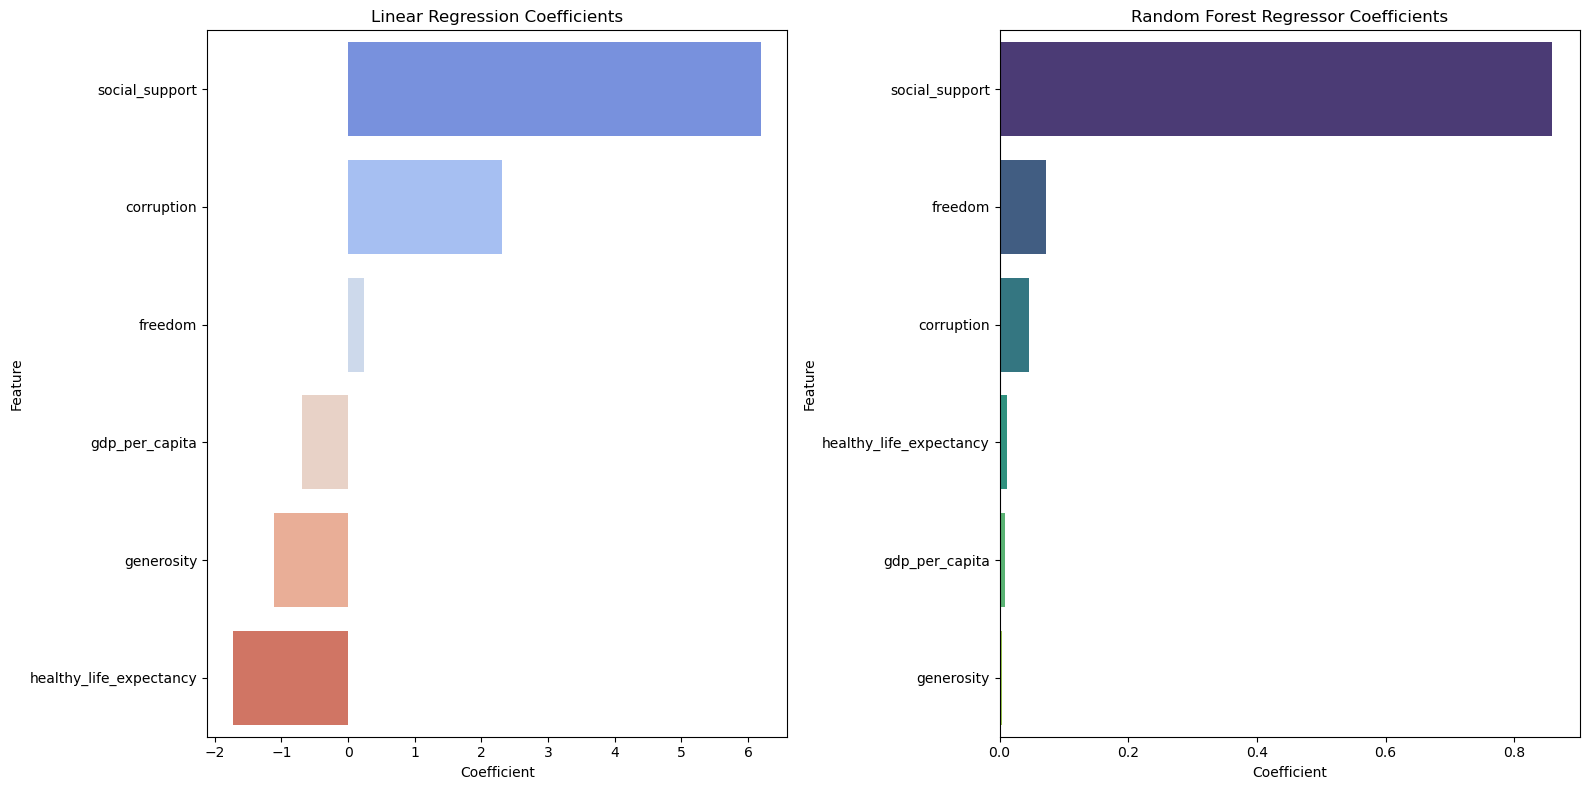

In [86]:
fig, axes = plt.subplots(1, 2, figsize = (16,8))
sns.barplot(x="Coefficient", y="Feature", data = lr_feat_importance, ax = axes[0],hue = "Feature", palette ="coolwarm")
axes[0].set_title("Linear Regression Coefficients")

sns.barplot(x = "Coefficient", y = "Feature", data = rf_feat_importance, ax = axes[1], hue = "Feature", palette = "viridis")
axes[1].set_title("Random Forest Regressor Coefficients")

plt.tight_layout()
plt.savefig('feature_importance_comparison.png')
plt.show()

## Conclusion: Predicting Global Happiness and Model Insights

#### Performance Overview

    Our machine learning models achieved incredible R2 Scores as it is excepted. It is a known fact that there is a robust impact of our given features with our target variable.

#### Multicollinearity
    In our Linear Regression model, Healthy Life Expectancy showed a counter-intuitive negative coefficient. And we all know this does not make any sense. So we can not say that health reduces happiness. It is a mathematical artifact caused by its extremely high correlation with GDP per Capita and Social Support. Since there are so many of features highly correlated, I did not want to drop this column entirely.

    When features are "tightly coupled", the model struggles to isolate the independent impact of each, leading to unstable coefficient signs.

#### Bimodal Distrubution
    Our EDA highlighted a bimodal distribution in happiness. Which means if a country is underdeveloped, it is so hard to beat all the hurdles and develop itself. It is a "Low Happiness Trap".

### Actionable Insights
    Our final coefficient graph shows that, Social Support is the single most dominant predictor of all well-being across all models. For policymakers and business architects, this emphasizes that while economic growth is essential, the "social infrastructure" and "community support systems" provide the highest ROI (Return on Investment) for human happiness.